In [0]:
import pandas as pd

### EDA workflow

## Objective:
1.Data loading, shape, dtypes, missing values, stats, distributions, correlations

2.Choosing the right visualization library for each situation

3.Reproduce the same chart in matplotlib, seaborn, plotly - understanding the trade-offs

4.Ask and answer the analytical questions about our dataset

### Visualization

### Exercise to follow

### Reading table data and converting to pandas

In [0]:
df= spark.table("workspace.default.bright_coffee_shop_sale").toPandas()
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,1899-12-31 07:06:11,2,5,Lower Manhattan,32,3.0000000000000000,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,1899-12-31 07:08:56,2,5,Lower Manhattan,57,3.1000000000000000,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,1899-12-31 07:14:04,2,5,Lower Manhattan,59,4.5000000000000000,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,1899-12-31 07:20:24,1,5,Lower Manhattan,22,2.0000000000000000,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,1899-12-31 07:22:41,2,5,Lower Manhattan,57,3.1000000000000000,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


### Demonstrating multiple ways of reading table data using pandas

In [0]:
#dd = spark.read.table("workspace.default.bright_coffee_shop_sale").toPandas()
#dd.head(3)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,1899-12-31 07:06:11,2,5,Lower Manhattan,32,3.0000000000000000,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,1899-12-31 07:08:56,2,5,Lower Manhattan,57,3.1000000000000000,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,1899-12-31 07:14:04,2,5,Lower Manhattan,59,4.5000000000000000,Drinking Chocolate,Hot chocolate,Dark chocolate Lg


In [0]:
# To understand the number of rows and columns in the dataset

df.shape

(149116, 11)

In [0]:
# Another way to show a random portion or sample of a data, similar to df.head()

df.sample(5)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
87753,88007,2023-05-08,1899-12-31 09:01:56,1,8,Hell's Kitchen,71,3.7500000000000000,Bakery,Pastry,Chocolate Croissant
26974,27031,2023-02-17,1899-12-31 13:26:40,1,5,Lower Manhattan,37,3.0000000000000000,Coffee,Barista Espresso,Espresso shot
137574,137911,2023-06-20,1899-12-31 19:33:43,1,3,Astoria,19,6.4000000000000000,Packaged Chocolate,Drinking Chocolate,Dark chocolate
110936,111190,2023-05-29,1899-12-31 08:27:06,1,5,Lower Manhattan,78,4.5000000000000000,Bakery,Scone,Scottish Cream Scone
8901,8931,2023-01-16,1899-12-31 11:48:30,2,3,Astoria,58,3.5000000000000000,Drinking Chocolate,Hot chocolate,Dark chocolate Rg


In [0]:
# How to show data type, please take note that dtype()function works with numpys only!

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  object        
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 12.5+ MB


Analysing above we realize the data has no NULLS, the Unit Price Column is an object and the Transaction_time column needs to be converted to time only instead of date time.

In [0]:
# Now listing our columns using pandas

df.columns.tolist()

['transaction_id',
 'transaction_date',
 'transaction_time',
 'transaction_qty',
 'store_id',
 'store_location',
 'product_id',
 'unit_price',
 'product_category',
 'product_type',
 'product_detail']

In [0]:
# Checking Missisng Values

# If we do not sum the nulls, data is not easily readable

df.isnull()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
149111,False,False,False,False,False,False,False,False,False,False,False
149112,False,False,False,False,False,False,False,False,False,False,False
149113,False,False,False,False,False,False,False,False,False,False,False
149114,False,False,False,False,False,False,False,False,False,False,False


In [0]:
# Check missing values, if we sum() the functions it's more readable

df.isnull().sum()

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64

<Axes: >

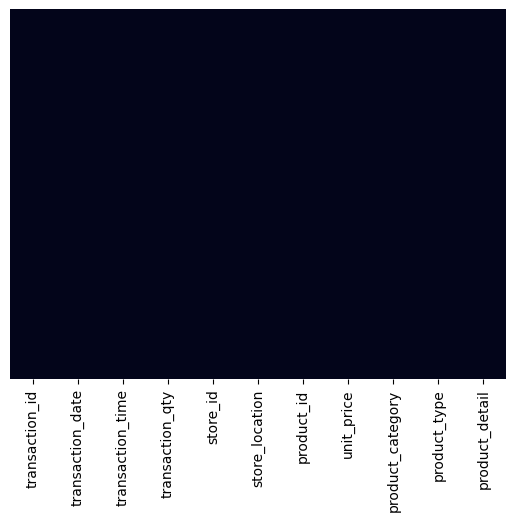

In [0]:
# Now doing Visual Check
#The Visual colour below is black NO multiple colours because there is only 1 value being "no-nulls". if we had multiple values it would show different colors based on values

import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

### Summary Stats below:

In [0]:
# Numeric summary, only gives columns whose values are numeric

df.describe()

,transaction_id,transaction_qty,store_id,product_id
count,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607
std,43153.600016,0.542509,2.074241,17.930020
min,1.000000,1.000000,3.000000,1.000000
25%,37335.750000,1.000000,3.000000,33.000000
50%,74727.500000,1.000000,5.000000,47.000000
75%,112094.250000,2.000000,8.000000,60.000000
max,149456.000000,8.000000,8.000000,87.000000


In [0]:
# Categorical summary, like the one above gives columns whose values are objects. We refer to them as categoric

df.describe(include = "object")

,store_location,unit_price,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,3,41,9,29,80
top,Hell's Kitchen,3.0000000000000000,Coffee,Brewed Chai tea,Chocolate Croissant
freq,50735,33703,58416,17183,3076


In [0]:
# Value Count for columns

df["product_category"].value_counts()

Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: product_category, dtype: int64

<Axes: >

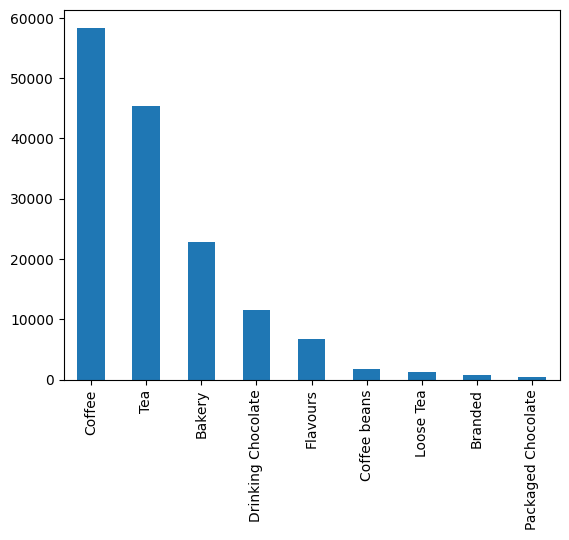

In [0]:
# Visualize the data count above, now copy code as is and .plot() fucntion - this is with pandas

df["product_category"].value_counts().plot(kind = "bar")

In [0]:
import matplotlib.pyplot as plt

<Axes: >

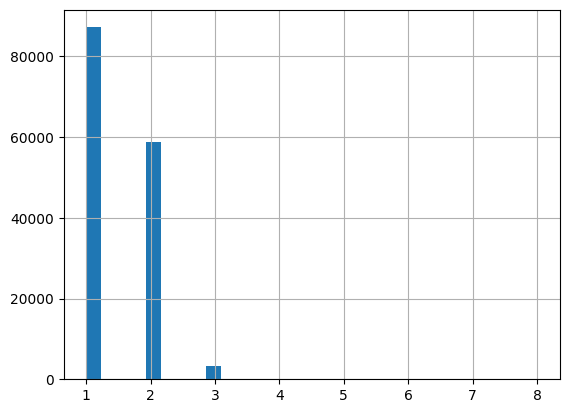

In [0]:
# Example of Matplotlib graphs

df["transaction_qty"].hist(bins= 30)  #bins are buckets in a simple terms works with continuous numbers

In [0]:
df["transaction_qty"].plot.bar()
plt.show()

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:719)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:439)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:439)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

### Relationships graphs:

In [0]:
# Visualize a relational graph or correlation

df.corr(numeric_only=True)

,transaction_id,transaction_qty,store_id,product_id
transaction_id,1.000000,0.010250,-0.006054,0.001076
transaction_qty,0.010250,1.000000,-0.000794,-0.175255
store_id,-0.006054,-0.000794,1.000000,0.025727
product_id,0.001076,-0.175255,0.025727,1.000000


In [0]:
# Almost similar output to the one on top except 'spearman' is used when data is skewed - no balance at all.

#All negatives below represent a negative correlation meaning if 1 increases the other decreases or remains the same. Positive corr means if one increases the ohter increases as well. The higher the number the stronger the correlation.

df.corr(numeric_only=True, method = 'spearman')

,transaction_id,transaction_qty,store_id,product_id
transaction_id,1.000000,0.006562,-0.006079,0.000550
transaction_qty,0.006562,1.000000,0.007938,-0.174417
store_id,-0.006079,0.007938,1.000000,0.026123
product_id,0.000550,-0.174417,0.026123,1.000000


<Axes: >

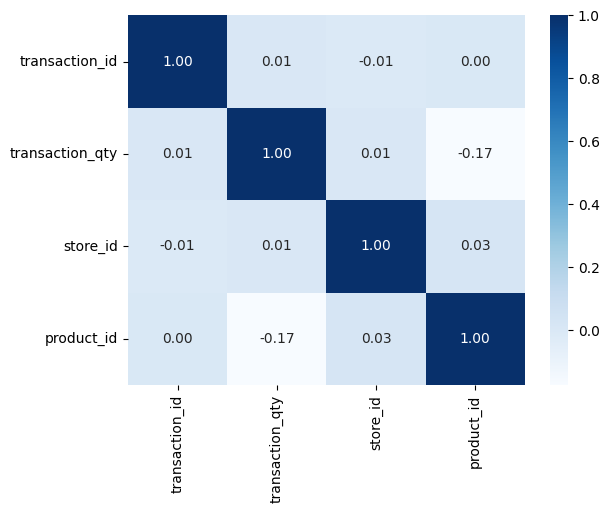

In [0]:
sns.heatmap(df.corr(numeric_only=True, method = "spearman"),annot=True, fmt=".2f", cmap= "Blues")

### GroupBy